In [1]:
print('Work By: \nRhugved Bhojane')

Work By: 
Rhugved Bhojane


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import os
import math
%matplotlib inline

In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
# Reload all modules imported with %aimport
%load_ext autoreload
%autoreload 1
# Import bankruptcy_helper module
import bankruptcy_helper
%aimport bankruptcy_helper
helper = bankruptcy_helper.Helper()

In [4]:
DATA_DIR = "./Data"
if not os.path.isdir(DATA_DIR):
    DATA_DIR = "../resource/asnlib/publicdata/bankruptcy/data"
data_file = "5th_yr.csv"
data = pd.read_csv( os.path.join(DATA_DIR, "train", data_file) )
target_attr = "Bankrupt"
n_samples, n_attrs = data.shape
print("Date shape: ", data.shape)

Date shape:  (4818, 66)


In [5]:
data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X57,X58,X59,X60,X61,X62,X63,X64,Bankrupt,Id
0,0.025417,0.41769,0.0568,1.1605,-126.39,0.41355,0.025417,1.2395,1.16500,0.51773,...,0.049094,0.85835,0.12322,5.6167,7.4042,164.310,2.2214,1.334,0,4510
1,-0.023834,0.2101,0.50839,4.2374,22.034,0.058412,-0.027621,3.6579,0.98183,0.76855,...,-0.031011,1.01850,0.069047,5.7996,7.7529,26.446,13.802,6.4782,0,3537
2,0.030515,0.44606,0.19569,1.565,35.766,0.28196,0.039264,0.88456,1.05260,0.39457,...,0.077337,0.95006,0.25266,15.049,2.8179,104.730,3.4852,2.6361,0,3920
3,0.052318,0.056366,0.54562,10.68,438.2,0.13649,0.058164,10.853,1.02790,0.61173,...,0.085524,0.97282,0,6.0157,7.4626,48.756,7.4863,1.0602,0,1806
4,0.000992,0.49712,0.12316,1.3036,-71.398,0,0.001007,1.0116,1.29210,0.50288,...,0.001974,0.99925,0.019736,3.4819,8.582,114.580,3.1854,2.742,0,1529


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4818 entries, 0 to 4817
Data columns (total 66 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   X1        4818 non-null   object 
 1   X2        4818 non-null   object 
 2   X3        4818 non-null   object 
 3   X4        4818 non-null   object 
 4   X5        4818 non-null   object 
 5   X6        4818 non-null   object 
 6   X7        4818 non-null   object 
 7   X8        4818 non-null   object 
 8   X9        4818 non-null   float64
 9   X10       4818 non-null   object 
 10  X11       4818 non-null   object 
 11  X12       4818 non-null   object 
 12  X13       4818 non-null   float64
 13  X14       4818 non-null   object 
 14  X15       4818 non-null   object 
 15  X16       4818 non-null   object 
 16  X17       4818 non-null   object 
 17  X18       4818 non-null   object 
 18  X19       4818 non-null   float64
 19  X20       4818 non-null   float64
 20  X21       4818 non-null   obje

In [7]:
from bankruptcy_helper import Helper
helper=Helper()

In [8]:
train_folder = "./train"
holdout_folder = "./holdout"

In [9]:
train_data, holdout_data = helper.load_data_from_folders(train_folder, holdout_folder)

In [10]:
if 'Id' in train_data.columns:
    train_data.drop(columns=['Id'], inplace=True)
if 'Id' in holdout_data.columns:
    holdout_data.drop(columns=['Id'], inplace=True)

In [11]:
missing_cols = set(train_data.columns) - set(holdout_data.columns)
for col in missing_cols:
    holdout_data[col] = np.nan

In [12]:
holdout_data = holdout_data[train_data.columns.drop('Bankrupt', errors='ignore')]

In [13]:
print("Train Data Shape:", train_data.shape)
print("Holdout Data Shape:", holdout_data.shape)
print("Missing Values in Train Data:")
print(train_data.isnull().sum())

Train Data Shape: (4818, 65)
Holdout Data Shape: (1092, 64)
Missing Values in Train Data:
X1          0
X2          0
X3          0
X4          0
X5          0
           ..
X61         0
X62         0
X63         0
X64         0
Bankrupt    0
Length: 65, dtype: int64


In [14]:
train_data.replace('?', np.nan, inplace=True)
holdout_data.replace('?', np.nan, inplace=True)

In [15]:
train_data = train_data.apply(pd.to_numeric, errors='coerce')
holdout_data = holdout_data.apply(pd.to_numeric, errors='coerce')

In [16]:
X_train = train_data.drop(columns=['Bankrupt'])
y_train = train_data['Bankrupt']
X_holdout = holdout_data

In [19]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train = train_data.drop(columns=['Bankrupt'])
y_train = train_data['Bankrupt']
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_holdout = pd.DataFrame(imputer.transform(holdout_data.drop(columns=['Bankrupt'], errors='ignore')), columns=X_train.columns)

In [23]:
from sklearn.feature_selection import SelectKBest, f_classif
X_train = train_data.drop(columns=['Bankrupt'])
y_train = train_data['Bankrupt']
selector = SelectKBest(score_func=f_classif, k=10) 
X_train_selected = selector.fit_transform(X_train, y_train)
selected_features = X_train.columns[selector.get_support()]
print("Top 10 Features Selected:", selected_features.tolist())

Top 10 Features Selected: ['X2', 'X3', 'X7', 'X9', 'X14', 'X29', 'X32', 'X39', 'X51', 'X56']


In [24]:
X_train = X_train[selected_features]
X_holdout = X_holdout[selected_features]

In [25]:
y_train = (y_train > 0).astype(int)

In [26]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [27]:
X_train_scaled, y_train_resampled = helper.preprocess_data(X_train_resampled.values, y_train_resampled.values)
X_holdout_scaled = helper.preprocess_data(X_holdout.values, None)[0]

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
log_reg = LogisticRegression(max_iter=5000, random_state=42, verbose=1)
log_reg.fit(X_train_scaled, y_train_resampled)

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  6.93147D-01    |proj g|=  1.49742D-01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   11     41     45      1     0     0   7.418D-05   5.523D-01
  F =  0.55228730194525621     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


 This problem is unconstrained.


LogisticRegression(max_iter=5000, random_state=42, verbose=1)

In [31]:
holdout_predictions = log_reg.predict_proba(X_holdout_scaled)[:, 1]  
holdout_results = pd.DataFrame({"Probability_of_Bankruptcy": holdout_predictions})

In [32]:
print(holdout_results) 

      Probability_of_Bankruptcy
0                      0.285539
1                      0.991404
2                      0.338866
3                      0.727572
4                      0.120932
...                         ...
1087                   0.031898
1088                   0.478077
1089                   0.893218
1090                   0.856585
1091                   0.410944

[1092 rows x 1 columns]


In [33]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import confusion_matrix, classification_report

In [34]:
y_pred_train = log_reg.predict(X_train_scaled)
conf_matrix = confusion_matrix(y_train_resampled, y_pred_train)
class_report = classification_report(y_train_resampled, y_pred_train)

<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 14.722222222222216, 'Predicted')

Text(45.72222222222221, 0.5, 'Actual')

Text(0.5, 1.0, 'Confusion Matrix - Training Set')

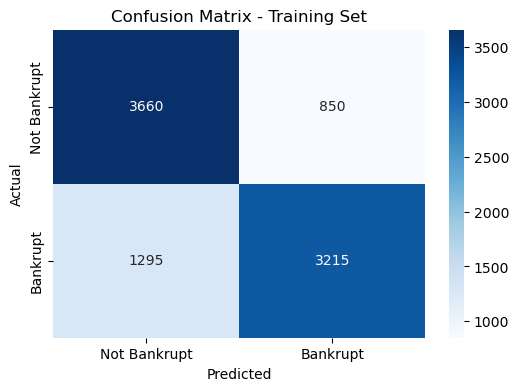

In [35]:
import seaborn as sns 
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Bankrupt", "Bankrupt"], yticklabels=["Not Bankrupt", "Bankrupt"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Training Set")
plt.show()